In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
path = r"C:\Users\anits-csm\Desktop\charancsm\BostonHousing.csv"

data = pd.read_csv(path)

print("Dataset Shape:", data.shape)
print("\nFirst 5 Rows:")
print(data.head())

Dataset Shape: (506, 14)

First 5 Rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [47]:
data.columns = data.columns.str.strip()


In [48]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [49]:
imputer = SimpleImputer(strategy="mean")

numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])


In [51]:
X = data.drop("medv", axis=1)
y = data["medv"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


In [53]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}


In [54]:
results = []

print("\nModel Comparison")
print("=" * 70)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

    print("\nModel:", name)
    print("MAE      :", round(mae, 3))
    print("MSE      :", round(mse, 3))
    print("RMSE     :", round(rmse, 3))
    print("R2 Score :", round(r2, 4))



Model Comparison

Model: Linear Regression
MAE      : 3.206
MSE      : 24.405
RMSE     : 4.94
R2 Score : 0.6672

Model: Decision Tree
MAE      : 2.268
MSE      : 8.38
RMSE     : 2.895
R2 Score : 0.8857

Model: Random Forest
MAE      : 2.043
MSE      : 7.854
RMSE     : 2.802
R2 Score : 0.8929


In [55]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("\nFinal Comparison")
print(results_df)


Final Comparison
               Model       MAE        MSE      RMSE  R2 Score
0  Linear Regression  3.206404  24.404825  4.940124  0.667209
1      Decision Tree  2.267647   8.380294  2.894874  0.885724
2      Random Forest  2.042706   7.853504  2.802410  0.892907


In [56]:
best_model = results_df.loc[results_df["R2 Score"].idxmax()]

print("\nBest Model")
print("-----------")
print("Model:", best_model["Model"])
print("R2 Score:", round(best_model["R2 Score"], 4))


Best Model
-----------
Model: Random Forest
R2 Score: 0.8929


In [57]:
# ============================
# Select Best Model
# ============================

best_model_name = results_df.loc[results_df["R2 Score"].idxmax(), "Model"]
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)

# ============================
# Predict House Prices
# ============================

predictions = best_model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

print("\nActual vs Predicted Prices")
print(prediction_df.head(10))


Best Model: Random Forest

Actual vs Predicted Prices
   Actual Price  Predicted Price
0          23.6           22.752
1          32.4           30.611
2          13.6           16.457
3          22.8           23.647
4          16.1           16.795
5          20.0           21.138
6          17.8           19.253
7          14.0           15.837
8          19.6           21.086
9          16.8           21.166


In [58]:
prediction_df.to_csv("HousePricePredictions.csv", index=False)
print("\nPredictions saved successfully.")


Predictions saved successfully.


In [59]:
print("\nFinal Accuracy Metrics")
print("MAE :", round(mean_absolute_error(y_test, predictions), 2))
print("MSE :", round(mean_squared_error(y_test, predictions), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, predictions)), 2))
print("R2 Score:", round(r2_score(y_test, predictions), 4))


Final Accuracy Metrics
MAE : 2.04
MSE : 7.85
RMSE: 2.8
R2 Score: 0.8929


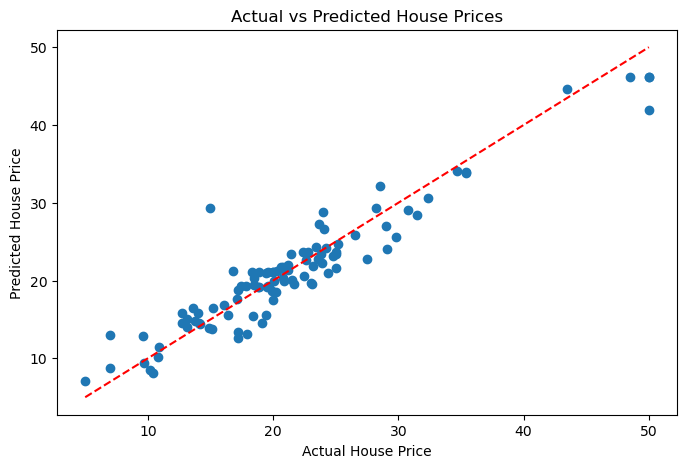

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [61]:
import pandas as pd

results = []

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append([name, mae, mse, rmse, r2])

# Create comparison table
comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("\nRegression Model Comparison")
print(comparison)


Regression Model Comparison
               Model       MAE        MSE      RMSE  R2 Score
0  Linear Regression  3.206404  24.404825  4.940124  0.667209
1      Decision Tree  2.267647   8.380294  2.894874  0.885724
2      Random Forest  2.042706   7.853504  2.802410  0.892907


In [62]:
best = comparison.loc[comparison["R2 Score"].idxmax()]

print("\nBest Regression Model")
print("---------------------")
print("Model      :", best["Model"])
print("MAE        :", round(best["MAE"], 2))
print("MSE        :", round(best["MSE"], 2))
print("RMSE       :", round(best["RMSE"], 2))
print("R2 Score   :", round(best["R2 Score"], 4))


Best Regression Model
---------------------
Model      : Random Forest
MAE        : 2.04
MSE        : 7.85
RMSE       : 2.8
R2 Score   : 0.8929


In [63]:
comparison = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print(comparison)


               Model       MAE        MSE      RMSE  R2 Score
0  Linear Regression  3.206404  24.404825  4.940124  0.667209
1      Decision Tree  2.267647   8.380294  2.894874  0.885724
2      Random Forest  2.042706   7.853504  2.802410  0.892907


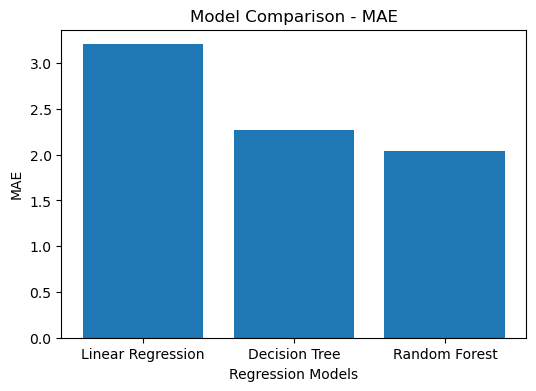

In [67]:
# MAE Plot
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["MAE"])
plt.title("Model Comparison - MAE")
plt.xlabel("Regression Models")
plt.ylabel("MAE")
plt.show()


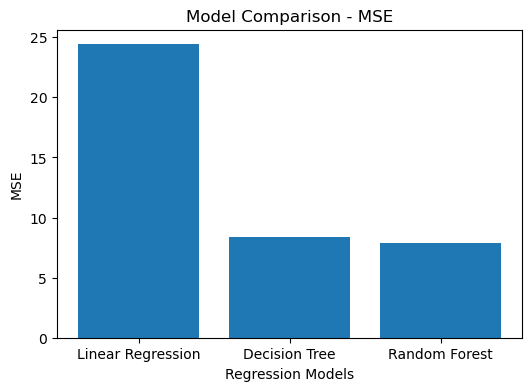

In [65]:
# MSE Plot
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["MSE"])
plt.title("Model Comparison - MSE")
plt.xlabel("Regression Models")
plt.ylabel("MSE")
plt.show()

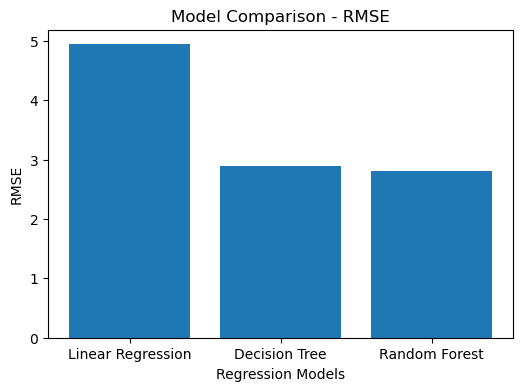

In [66]:
# RMSE Plot
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.title("Model Comparison - RMSE")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.show()

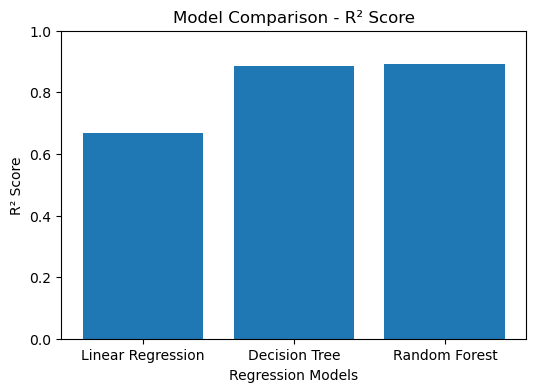

In [68]:
# R² Score Plot
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.title("Model Comparison - R² Score")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()